# 3 Quarantine

Here we show how quarantine is implemented in the model and how it affects the model.

In [1]:
import numpy as np

from EpiCommute import SIRModel

# Model setup

We again use a simple system, with a random mobility `mobility_baseline`.

Now we assume that mobility has been reduced due to lockdown measures. The new mobility is given by the matrix `mobility_current`, which is simply the baseline mobility flows reduced by random factors.

In [2]:
# Number and size of subpopulations
M = 20
subpopulation_sizes = np.random.randint(20,100,M)

# Initialize a random mobility matrix
mobility_baseline = np.random.rand(M, M)

# We assume mobility has decreased due to lockdown
mobility_current = mobility_baseline * (( np.random.rand(M,M) *0.5 ) + 0.5 )

In [9]:
mobility_baseline

array([[0.74112467, 0.19767503, 0.73237817, 0.70785095, 0.60291429,
        0.16560208, 0.44042665, 0.93765138, 0.37054686, 0.07295182,
        0.68456184, 0.51746623, 0.48246143, 0.69263706, 0.06905228,
        0.37519765, 0.3263449 , 0.80186188, 0.64448624, 0.23002356],
       [0.55699889, 0.09097804, 0.36133934, 0.61319439, 0.52165992,
        0.90144423, 0.54089197, 0.19075767, 0.00457712, 0.85014729,
        0.00765036, 0.03556816, 0.31098042, 0.66762617, 0.60645637,
        0.80042893, 0.71020249, 0.41046787, 0.66698057, 0.40838158],
       [0.51299271, 0.05875887, 0.77592886, 0.56765983, 0.68570427,
        0.82191303, 0.10995445, 0.10558844, 0.23629991, 0.79193077,
        0.84162264, 0.12023483, 0.32517879, 0.42740847, 0.58678505,
        0.68330026, 0.08461898, 0.68802826, 0.1089146 , 0.92446262],
       [0.12569143, 0.72358114, 0.65660252, 0.61851801, 0.9906327 ,
        0.09912517, 0.76942154, 0.35381681, 0.1426842 , 0.17129432,
        0.40605097, 0.27133228, 0.98203906, 0

## Quarantine scenarios

Quarantine is implemented in two different ways in the model:

 - The `isolation` scenario assumes that the reduced mobility means that individual stay at home, and are effectively removed from the dynamices.
 - The `distancing` scenario instead assumes that the reduced mobility corresponds to a reduction in contacts between individuals.
 
More detailed descriptions of both scenarios are given in the manuscript.

## Initialize and run scenarios

We now initialize and run three different variations of the model: no quarantine, isolation, and distancing.


In [3]:
model_no_quarantine = SIRModel(
            mobility_baseline,
            subpopulation_sizes,
            quarantine_mode = None,
            outbreak_source=0,
            VERBOSE=True
        )

model_isolation = SIRModel(
            mobility_current,
            subpopulation_sizes,
            mobility_baseline=mobility_baseline,   
            quarantine_mode = 'isolation',
            outbreak_source=0,
            VERBOSE=True
        )

model_distancing = SIRModel(
            mobility_current,
            subpopulation_sizes,
            mobility_baseline=mobility_baseline,   
            quarantine_mode = 'distancing',
            outbreak_source=0,
            VERBOSE=True
        )

Run simulations

In [4]:
results_no_quarantine = model_no_quarantine.run_simulation()

Starting Simulation ...
Simulation completed
Time: 0min 2.34s


In [5]:
results_isolation = model_isolation.run_simulation()

Starting Simulation ...
Simulation completed
Time: 0min 2.01s


In [6]:
results_distancing = model_distancing.run_simulation()

Starting Simulation ...
Simulation completed
Time: 0min 2.39s


## Comparison of results

We can see that both quarantine-scenarios "flatten the curve". 

The ``isolation`` scenario shows a flatter curve on average (but as we only run one simulation this doesn't have to be the case.

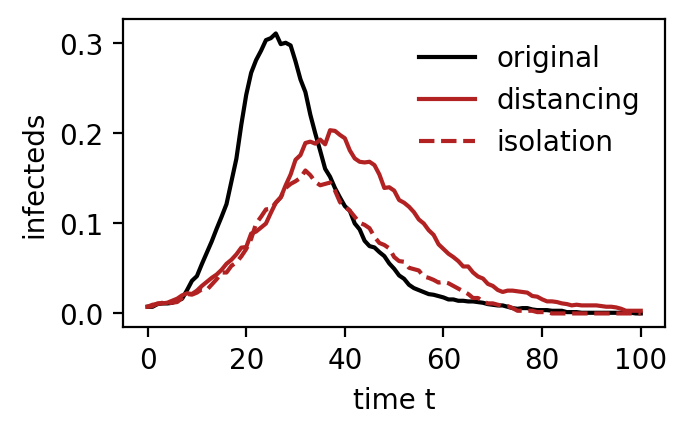

In [7]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('figure', dpi=200)

fig = plt.figure(figsize=(3.5,2))
plt.plot(results_no_quarantine['t'], results_no_quarantine['I_total'], label='original', color='k')
plt.plot(results_distancing['t'], results_distancing['I_total'], label='distancing', color='firebrick')
plt.plot(results_isolation['t'], results_isolation['I_total'], label='isolation', color='firebrick', linestyle='--')

plt.legend(frameon=False)
plt.xlabel("time t")
plt.ylabel("infecteds")
plt.show()